In [2]:
import numpy as np
import matplotlib.pyplot as plt

Calculating returns for Gamma type: fixed_low
Calculating returns for Gamma type: fixed_high
Calculating returns for Gamma type: dynamic
Calculating returns for Gamma type: dynamic_nonlinear


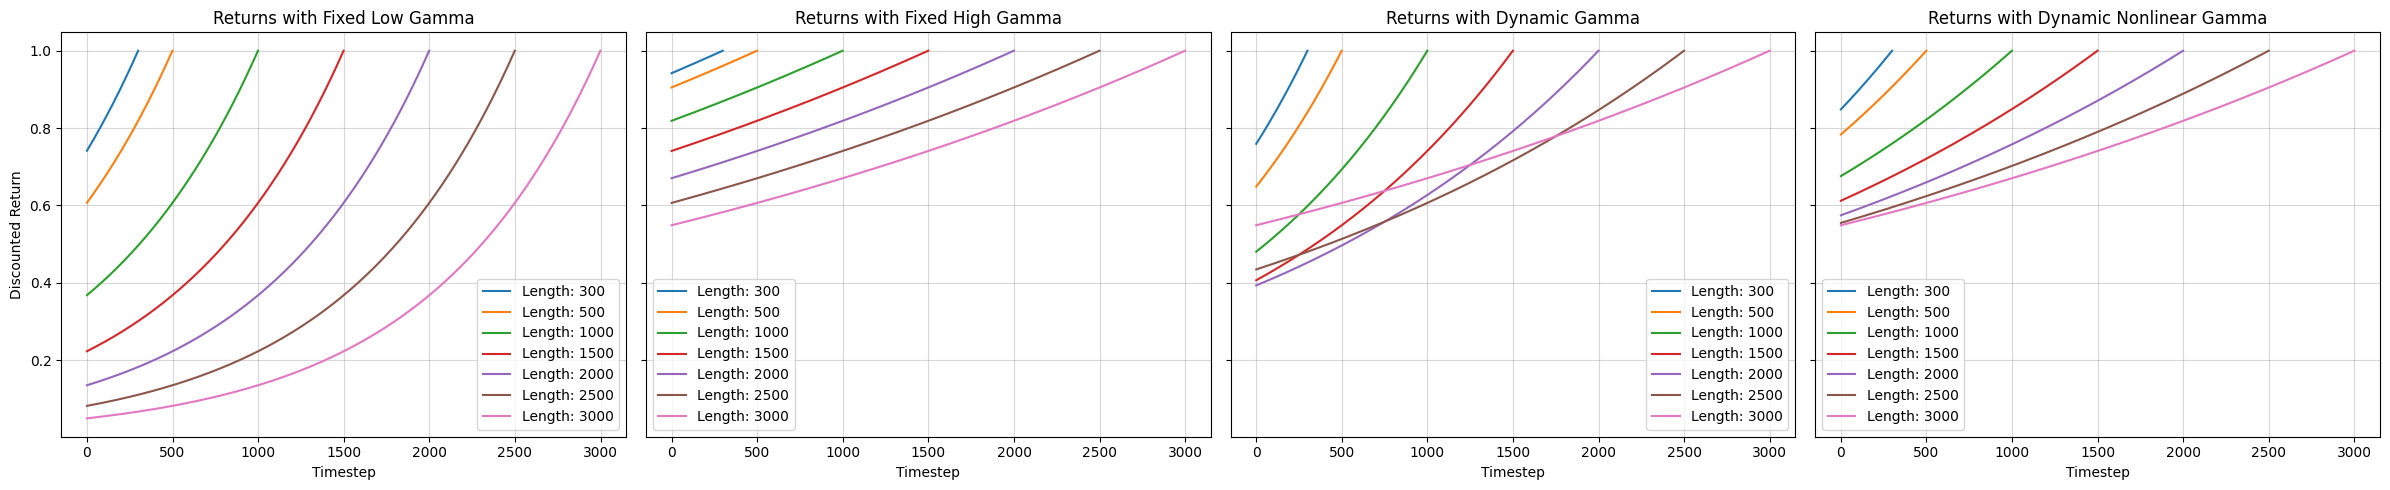

In [ ]:
def get_dynamic_discount(episode_length, min_gamma=0.999, max_gamma=0.9998, max_expected_length=10000):
    """
    Dynamically calculates the discount rate based on the episode length.

    Args:
        episode_length (int): The length of the current episode.
        min_gamma (float): The minimum discount rate.
        max_gamma (float): The maximum discount rate.
        max_expected_length (int): The maximum expected episode length in the environment.

    Returns:
        float: The dynamically adjusted discount rate.
    """
    # Normalize episode length to be between 0 and 1 based on max_expected_length
    normalized_length = min(episode_length / max_expected_length, 1.0)  # Cap at 1 if episode exceeds max_expected_length
    # Linearly interpolate gamma between min_gamma and max_gamma
    gamma = min_gamma + (max_gamma - min_gamma) * normalized_length
    return gamma


def get_dynamic_discount_nonlinear(
    episode_length, min_gamma=0.999, max_gamma=0.9998, max_expected_length=10000, nonlinear_scaling_factor=3
):
    """
    Dynamically calculates the discount rate with nonlinear scaling based on episode length.

    Args:
        episode_length (int): The length of the current episode.
        min_gamma (float): Minimum discount rate.
        max_gamma (float): Maximum discount rate.
        max_expected_length (int): Maximum expected episode length.
        nonlinear_scaling_factor (float): Factor to adjust the nonlinearity of the discount curve.

    Returns:
        float: Adjusted discount rate.
    """
    normalized_length = min(episode_length / max_expected_length, 1.0)
    # Apply nonlinear scaling to emphasize longer episodes
    scaled_length = normalized_length**nonlinear_scaling_factor
    gamma = min_gamma + (max_gamma - min_gamma) * scaled_length
    return gamma


def calculate_returns(rewards, gamma):
    """
    Calculates the discounted returns for a sequence of rewards.

    Args:
        rewards (list or np.ndarray): A list of rewards for an episode.
        gamma (float): The discount rate.

    Returns:
        np.ndarray: An array of discounted returns for each timestep.
    """
    returns = np.zeros_like(rewards, dtype=float)
    R = 0
    for t in reversed(range(len(rewards))):
        R = rewards[t] + gamma * R
        returns[t] = R
    return returns


def visualize_returns(episode_lengths, gammas, all_returns):
    """
    Visualizes the discounted returns for different episode lengths and discount rates.

    Args:
        episode_lengths (list): List of episode lengths tested.
        gammas (dict): Dictionary of gamma types ('fixed_low', 'fixed_high', 'dynamic') and their values/methods.
        all_returns (dict): Dictionary storing returns for each gamma type and episode length.
    """
    num_gammas = len(gammas)
    fig, axes = plt.subplots(1, num_gammas, figsize=(6 * num_gammas, 5), sharey=True)  # Adjust figsize as needed

    if not isinstance(axes, np.ndarray):  # Handle case with only one subplot
        axes = [axes]

    for i, gamma_type in enumerate(gammas):
        ax = axes[i]
        ax.set_title(f'Returns with {gamma_type.replace("_", " ").title()} Gamma')
        ax.set_xlabel('Timestep')
        if i == 0:
            ax.set_ylabel('Discounted Return')

        for length in episode_lengths:
            returns = all_returns[gamma_type][length]
            ax.plot(returns, label=f'Length: {length}')

        ax.legend()
        ax.grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()


# Define parameters
# episode_lengths_to_test = [300, 500, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
episode_lengths_to_test = [300, 500, 1000, 1500, 2000, 2500, 3000]
min_gamma_val = 0.999
max_gamma_val = 0.9997
max_expected_episode_length = 3000
nonlinear_scaling_factor = 0.25

# Define different gamma strategies
gamma_strategies = {
    'fixed_low': min_gamma_val,
    'fixed_high': max_gamma_val,
    'dynamic': lambda length: get_dynamic_discount(length, min_gamma_val, max_gamma_val, max_expected_episode_length),
    'dynamic_nonlinear': lambda length: get_dynamic_discount_nonlinear(
        length, min_gamma_val, max_gamma_val, max_expected_episode_length, nonlinear_scaling_factor
    ),
}

all_calculated_returns = {}

for gamma_type, gamma_value in gamma_strategies.items():
    print(f"Calculating returns for Gamma type: {gamma_type}")
    all_calculated_returns[gamma_type] = {}
    for episode_length in episode_lengths_to_test:
        # print(f"  Episode length: {episode_length}")
        reward_t = 1.0
        rewards = [0] * (episode_length - 1) + [reward_t]

        # Get gamma value (either fixed or dynamic)
        if callable(gamma_value):  # If gamma_value is a function (for dynamic)
            current_gamma = gamma_value(episode_length)
        else:  # For fixed gamma values
            current_gamma = gamma_value

        returns = calculate_returns(rewards, current_gamma)
        all_calculated_returns[gamma_type][episode_length] = returns

# Visualize the results
visualize_returns(episode_lengths_to_test, gamma_strategies, all_calculated_returns)